In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------
# 1. Check GPU availability
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# -----------------------
# 2. Load and preprocess
# -----------------------
# California Housing dataset:
# Features (X):
#  - MedInc:    Median income in block group
#  - HouseAge:  Median house age in block group
#  - AveRooms:  Average number of rooms per household
#  - AveBedrms: Average number of bedrooms per household
#  - Population: Block group population
#  - AveOccup:  Average household size
#  - Latitude:  Block group latitude
#  - Longitude: Block group longitude
#
# Target (y):
#  - MedHouseVal: Median house value in $100,000s

housing = fetch_california_housing()
X, y = housing.data, housing.target

In [4]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [5]:
# Split into train+val and test (80/20)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Further split train+val into train and val (80/20 of trainval → 64/16 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

In [6]:
# Normalize features using training set only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# Convert to tensors and move to device
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device) #shapes output to (n, 1)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

In [8]:
X_train.shape

torch.Size([13209, 8])

In [9]:
X_train

tensor([[ 0.4434, -0.1245,  0.5205,  ...,  0.0517,  1.1028, -0.6916],
        [ 0.0032, -1.0777, -0.1708,  ..., -0.0552, -0.7249,  0.8544],
        [-0.5218, -0.2039, -0.0613,  ..., -0.0170, -0.8843,  0.8644],
        ...,
        [ 0.0611, -0.8394,  0.0611,  ...,  0.0311, -1.3623,  1.2933],
        [ 0.3399, -0.9983, -0.4748,  ..., -0.1376, -0.8468,  0.8544],
        [ 0.1752,  0.5110, -0.4947,  ..., -0.0077, -0.8140,  0.6300]],
       device='cuda:0')

In [10]:
# -----------------------
# 3. Define model
# -----------------------
class LinearRegressionModel(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.linear(x)


In [11]:
model = LinearRegressionModel(X_train.shape[1]).to(device) #initialising with input features so only columns not rows

In [12]:
# -----------------------
# 4. Loss and optimizer
# -----------------------
criterion = nn.MSELoss() #mean squared error
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [13]:
# -----------------------
# 5. Training loop
# -----------------------
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training ---
    model.train() #
    y_pred = model(X_train)
    train_loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

Epoch 10/100, Train Loss: 5.7570, Val Loss: 5.9396
Epoch 20/100, Train Loss: 5.0282, Val Loss: 5.0942
Epoch 30/100, Train Loss: 4.4682, Val Loss: 4.5211
Epoch 40/100, Train Loss: 4.0015, Val Loss: 4.0561
Epoch 50/100, Train Loss: 3.6006, Val Loss: 3.6419
Epoch 60/100, Train Loss: 3.2541, Val Loss: 3.2790
Epoch 70/100, Train Loss: 2.9488, Val Loss: 2.9642
Epoch 80/100, Train Loss: 2.6754, Val Loss: 2.6876
Epoch 90/100, Train Loss: 2.4282, Val Loss: 2.4400
Epoch 100/100, Train Loss: 2.2042, Val Loss: 2.2160


In [14]:
# -----------------------
# 6. Test Evaluation
# -----------------------
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    test_loss = criterion(y_pred_test, y_test).item()

print("\nFinal Test MSE:", test_loss)


Final Test MSE: 2.1897101402282715


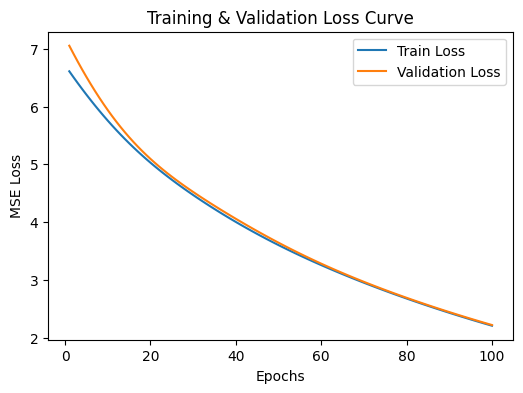

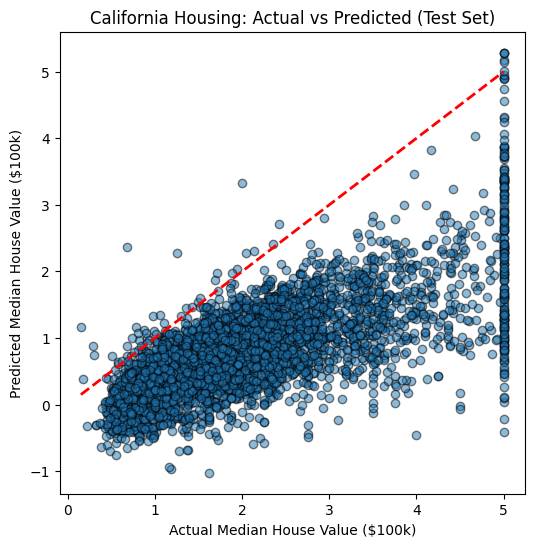

In [15]:
# -----------------------
# 7. Visualization
# -----------------------

# (A) Training vs Validation loss
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.show()

# (B) Predicted vs Actual scatter plot (Test set)
y_pred_test_np = y_pred_test.cpu().numpy().flatten()
y_test_np = y_test.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_test_np, y_pred_test_np, alpha=0.5, edgecolors="k")
plt.plot([y_test_np.min(), y_test_np.max()],
         [y_test_np.min(), y_test_np.max()],
         "r--", lw=2)  # perfect prediction line
plt.xlabel("Actual Median House Value ($100k)")
plt.ylabel("Predicted Median House Value ($100k)")
plt.title("California Housing: Actual vs Predicted (Test Set)")
plt.show()


##Q1)Review the framework documentation to see which loss functions are provided. In particular,replace the squared loss with Huber's robust loss function. That is, use the loss function
$$l(y,y')= \begin{cases}|y-y'| -\frac{\sigma}{2} & \textrm{ if } |y-y'| > \sigma \\ \frac{1}{2 \sigma} (y-y')^2 & \textrm{ otherwise}\end{cases}$$
[5 Marks]

In [16]:
updated_criterion=nn.HuberLoss(delta=0.5)

In [17]:
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training ---
    model.train()
    y_pred = model(X_train)
    train_loss = updated_criterion(y_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = updated_criterion(y_val_pred, y_val)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

Epoch 10/100, Train Loss: 0.4811, Val Loss: 0.4798
Epoch 20/100, Train Loss: 0.4667, Val Loss: 0.4661
Epoch 30/100, Train Loss: 0.4568, Val Loss: 0.4565
Epoch 40/100, Train Loss: 0.4483, Val Loss: 0.4483
Epoch 50/100, Train Loss: 0.4403, Val Loss: 0.4404
Epoch 60/100, Train Loss: 0.4324, Val Loss: 0.4326
Epoch 70/100, Train Loss: 0.4244, Val Loss: 0.4247
Epoch 80/100, Train Loss: 0.4163, Val Loss: 0.4168
Epoch 90/100, Train Loss: 0.4081, Val Loss: 0.4087
Epoch 100/100, Train Loss: 0.3999, Val Loss: 0.4006


In [18]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    test_loss = updated_criterion(y_pred_test, y_test).item()

print("\nFinal Test MSE:", test_loss)


Final Test MSE: 0.3985273241996765


---
### Observation on change of loss function
Observe drop in testing MSE from 1.39 to 0.26 (with delta=1) to 0.16 (with delta=0.5)

---

##Q2)How does the solution change as you vary the amount epochs?
Plot the estimation error for $|y-y'|$ as a function of the amount of data.
[**2** Marks]

In [19]:
epochs = 1000
mae_train = []
mae_val = []

for epoch in range(epochs):
    # --- Training ---
    model.train()
    y_pred = model(X_train)
    loss = updated_criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- Evaluation ---
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)   # <--- recompute here
        y_pred_val = model(X_val)

        train_mae = torch.mean(torch.abs(y_pred_train - y_train)).item()
        val_mae   = torch.mean(torch.abs(y_pred_val - y_val)).item()

    mae_train.append(train_mae)
    mae_val.append(val_mae)


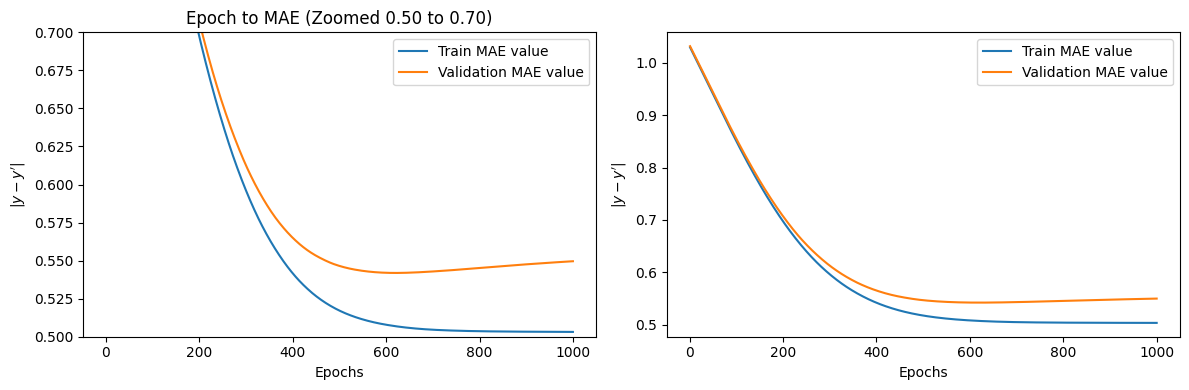

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, epochs+1), mae_train, label="Train MAE value")
axes[0].plot(range(1, epochs+1), mae_val, label="Validation MAE value")
axes[0].set_ylim(0.50, 0.70)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("$|y-y'|$")
axes[0].set_title("Epoch to MAE (Zoomed 0.50 to 0.70)")
axes[0].legend()

axes[1].plot(range(1, epochs+1), mae_train, label="Train MAE value")
axes[1].plot(range(1, epochs+1), mae_val, label="Validation MAE value")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("$|y-y'|$")
axes[1].legend()

plt.tight_layout()
plt.show()


##Q3)How does the solution change as you vary the training percentage?
Plot the estimation error for $|y-y'|$ as a function of the amount of data.
[3 Marks]

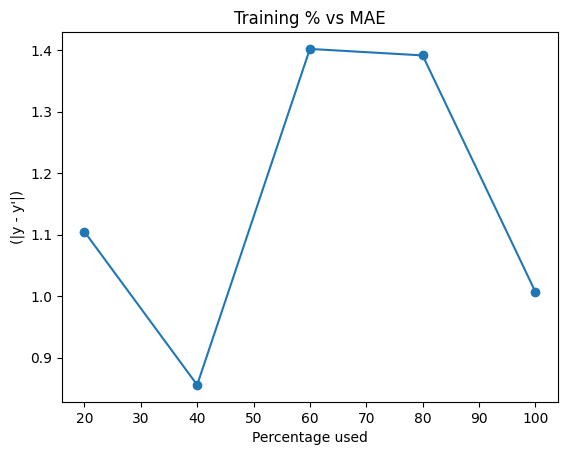

In [ ]:
X_train_iter, X_test_iter, y_train_iter, y_test_iter = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_iter = scaler.fit_transform(X_train_iter)
X_test_iter = scaler.transform(X_test_iter)

X_test_iter = torch.tensor(X_test_iter, dtype=torch.float32).to(device)
y_test_iter = torch.tensor(y_test_iter, dtype=torch.float32).view(-1, 1).to(device)

train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
test_mae_results = []

for size in train_sizes:
    n_samples = int(size * X_train_iter.shape[0])
    idx = np.random.choice(X_train_iter.shape[0], n_samples, replace=False)

    X_sub = X_train_iter[idx]
    y_sub = y_train_iter[idx]

    X_sub = torch.tensor(X_sub, dtype=torch.float32).to(device)
    y_sub = torch.tensor(y_sub, dtype=torch.float32).view(-1, 1).to(device)
    updated_criterion=nn.HuberLoss(delta=0.5)

    model = LinearRegressionModel(X_sub.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(100):
        model.train()
        y_pred = model(X_sub)
        loss = updated_criterion(y_pred, y_sub)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test)
        test_mae = torch.mean(torch.abs(y_test_pred - y_test)).item()

    test_mae_results.append(test_mae)

plt.plot([size*100 for size in train_sizes], test_mae_results, marker="o")
plt.xlabel("Percentage used")
plt.ylabel("(|y - y'|)")
plt.title("Training % vs MAE")
plt.show()
